**Imported Libraries**

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, classification_report
import xgboost as xgb
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("heart.csv")

**Preprocessing**

In [3]:
# Check for missing values
if df.isnull().sum().sum() > 0:
    print("Warning: Missing values detected. Fill them before training.")
else:
    print("✅ No missing values.")

# Split features and target
X = df.drop('target', axis=1)
y = df['target']

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


✅ No missing values.


**Data Split**

In [4]:
# Split into train/test
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Define base models
rf = RandomForestClassifier(n_estimators=100, random_state=42)
xgb_clf = xgb.XGBClassifier(n_estimators=150, learning_rate=0.1, max_depth=4, use_label_encoder=False, eval_metric='logloss')
lr = LogisticRegression()

# Define the stacking ensemble
stacked_model = StackingClassifier(
    estimators=[
        ('rf', rf),
        ('xgb', xgb_clf),
        ('lr', lr)
    ],
    final_estimator=LogisticRegression(),
    cv=5,
    n_jobs=-1
)


**Train the stacked model**

In [5]:
# Train the stacked model
stacked_model.fit(X_train, y_train)

# Make predictions
y_pred = stacked_model.predict(X_test)
y_prob = stacked_model.predict_proba(X_test)[:, 1]

# Evaluate performance
acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

print(f"\n🎯 Stacked Accuracy: {acc * 100:.2f}%")
print(f"📊 AUC Score: {auc:.4f}")
print("\n🧾 Classification Report:\n", classification_report(y_test, y_pred))



🎯 Stacked Accuracy: 85.25%
📊 AUC Score: 0.9321

🧾 Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.83      0.84        29
           1       0.85      0.88      0.86        32

    accuracy                           0.85        61
   macro avg       0.85      0.85      0.85        61
weighted avg       0.85      0.85      0.85        61



**Confusion Matrix**

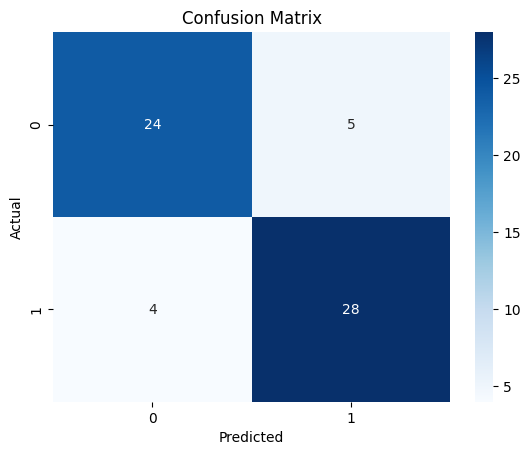

In [6]:
# Confusion Matrix
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, cmap="Blues", fmt="d")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

**Single Prediction**

In [7]:
# ----- SINGLE INSTANCE PREDICTION -----
# Input features: age, sex, cp, trestbps, chol, fbs, restecg, thalach, exang, oldpeak, slope, ca, thal
input_data = (63,1,3,145,233,1,0,150,0,2.3,0,0,1)  # (age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal)
# Preprocess input
input_data_as_numpy_array = np.asarray(input_data).reshape(1, -1)
input_data_scaled = scaler.transform(input_data_as_numpy_array)

# Predict using the trained stacked model
prediction = stacked_model.predict(input_data_scaled)

# Interpret and display prediction
if prediction[0] == 0:
    print('\n✅ **Prediction:** The person is **not at high risk** of heart disease.')
else:
    print('\n⚠️ **Warning:** The person **may have signs of heart disease**.')

# --- Suggestions Based on Prediction ---
if prediction[0] == 0:
    print('\n📌 **Recommendations for Low Risk:**')
    print('- Maintain a heart-healthy diet (low saturated fats, high fiber).')
    print('- Engage in regular physical activity (e.g., 150 mins/week of moderate exercise).')
    print('- Monitor blood pressure and cholesterol annually.')
    print('- Avoid smoking and limit alcohol intake.')
else:
    print('\n❗ **Urgent Recommendations for High Risk:**')
    print('- **Consult a cardiologist immediately** for further evaluation.')
    print('- Follow up with diagnostic tests (e.g., stress test, echocardiogram).')
    print('- Strictly manage blood pressure, cholesterol, and diabetes (if applicable).')
    print('- Adopt prescribed medications and lifestyle changes under medical supervision.')


⚠️ **Warning:** The person **may have signs of heart disease**.

❗ **Urgent Recommendations for High Risk:**
- **Consult a cardiologist immediately** for further evaluation.
- Follow up with diagnostic tests (e.g., stress test, echocardiogram).
- Strictly manage blood pressure, cholesterol, and diabetes (if applicable).
- Adopt prescribed medications and lifestyle changes under medical supervision.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


**CSV Prediction**

In [9]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

# Load the labeled dataset
df = pd.read_csv("/content/heart.csv")

# Separate features and true labels
X_new = df.iloc[:, :-1]  # All columns except the last
y_true = df.iloc[:, -1]  # The last column is the true label

# Apply the same scaler used during training
X_new_scaled = scaler.transform(X_new)

# Predict using the trained stacked model
y_pred = stacked_model.predict(X_new_scaled)

# Evaluate and print results
acc = accuracy_score(y_true, y_pred)
print(f"\n🎯 Accuracy on labeled dataset: {acc * 100:.2f}%")
print("\n🔍 Predicted Labels:\n", y_pred.tolist())
print("\n✅ True Labels:\n", y_true.tolist())



🎯 Accuracy on labeled dataset: 95.71%

🔍 Predicted Labels:
 [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

✅ True Labels:
 [1, 1, 1, 1,

In [10]:
import joblib

# Define the filename for the saved model
filename = 'stacked_heart_disease_model.pkl'

# Save the model
joblib.dump(stacked_model, filename)

print(f"✅ Model saved successfully as {filename}")

✅ Model saved successfully as stacked_heart_disease_model.pkl


In [ ]:

import joblib
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split


# Load the saved model
loaded_model = joblib.load('stacked_heart_disease_model.pkl')

# Define the feature names for clarity (should match the order used during training)
feature_names = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']

# Get user input for each feature
user_input = []
print("Please enter the values for the following features:")
for feature in feature_names:
    value = float(input(f"{feature}: "))
    user_input.append(value)

# Convert user input to a numpy array and reshape for prediction
input_data_as_numpy_array = np.asarray(user_input).reshape(1, -1)

# You will need to apply the same scaler used during training to the new input data
# If you saved the scaler, load it here and apply it.
# If not, you will need to retrain the scaler on your training data or use the existing scaler object if it's still in memory.
# Assuming 'scaler' object is still available from previous cells:
# from sklearn.preprocessing import StandardScaler # Uncomment if scaler object is not in memory
# scaler = StandardScaler() # Uncomment if scaler object is not in memory and you need to refit
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) # Uncomment if scaler object is not in memory and you need to refit
# scaler.fit(X_train) # Uncomment if scaler object is not in memory and you need to refit

# Create and fit the scaler (assuming you have access to the original training data or a representative sample)
# If you don't have access to the original training data, you should save and load the scaler along with the model.
# For demonstration, let's assume you have access to X (original features before splitting)
# If you don't have X, you'll need to load it or use a saved scaler.
# Since X is available in the kernel, we will use it to fit the scaler.
scaler = StandardScaler()
scaler.fit(X) # Use the original features (X) to fit the scaler


input_data_scaled = scaler.transform(input_data_as_numpy_array)


# Predict using the loaded model
prediction = loaded_model.predict(input_data_scaled)

# Interpret and display prediction
if prediction[0] == 0:
    print('\n✅ **Prediction:** The person is **not at high risk** of heart disease.')
else:
    print('\n⚠️ **Warning:** The person **may have signs of heart disease**.')

In [ ]:
import joblib

# Define the filename for the saved scaler
scaler_filename = 'scaler.pkl'

# Save the scaler
joblib.dump(scaler, scaler_filename)

print(f"✅ Scaler saved successfully as {scaler_filename}")